# 04_esrs_e1_checklist.ipynb
**Author:** Emma McCallum  
**Purpose:** Apply selected ESRS E1-inspired readiness indicators to BEGES data 
for five professional services firms  
**Input:** `data/processed/emissions_long.csv`, `data/processed/five_firms_full.csv`  
**Output:** `data/processed/esrs_scores.csv`, `figures/esrs_checklist.png`

## Important caveat

This notebook does not assess CSRD compliance. It applies selected ESRS E1-inspired 
readiness indicators to BEGES and ADEME structured data. A full ESRS E1 assessment 
would require the undertaking's sustainability statement, double materiality 
assessment, climate risks and opportunities, policies, financial effects, transition 
plan details, and assurance context. None of those are available in the ADEME export.

CSRD is already in force for Wave 1 firms. Wave 2 and Wave 3 reporting has been 
postponed by two years under the Stop-the-Clock Directive adopted in April 2025. 
The regulatory direction is clear even if exact timelines are shifting.

The question this notebook asks is: if these firms had to report under ESRS E1, 
how ready would their current BEGES be?

## ESRS E1 readiness criteria

Eight criteria are assessed, each scored 0 (not present) or 1 (present).
This is a binary scale because these elements either exist in the data or they do not.

| Criterion | What is checked | Data source |
|-----------|----------------|-------------|
| Scope 1 disclosed | Positive Scope 1 value reported | emissions_long.csv |
| Scope 2 disclosed | Positive Scope 2 value reported | emissions_long.csv |
| Scope 3 disclosed | Positive Scope 3 value reported | emissions_long.csv |
| Base year disclosed | Firm states a reference year | five_firms_full.csv |
| Near-term target | Reduction target for 2030 stated | five_firms_full.csv |
| Long-term target | 2050 or net zero target stated | five_firms_full.csv |
| Transition plan present | Action plan or climate strategy present | five_firms_full.csv |
| Scope 2 basis addressed | Location or market basis mentioned | five_firms_full.csv |

Maximum possible score: 8

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load emissions data for scope checks
emissions = pd.read_csv("../data/processed/emissions_long.csv")

# Load full firm data for text field checks
df = pd.read_csv("../data/processed/five_firms_full.csv")

# Keep most recent report per firm
df = df.sort_values("Année de reporting", ascending=False)
df = df.drop_duplicates(subset="Raison sociale", keep="first")

print(f"Firms loaded: {df['Raison sociale'].nunique()}")
print(f"Emissions rows: {len(emissions)}")
print()
print(df[["Raison sociale", "Année de reporting"]])

Firms loaded: 5
Emissions rows: 110

                Raison sociale  Année de reporting
5                   ECOCERT SA                2024
4  BUREAU VERITAS EXPLOITATION                2023
1                 ANTEA FRANCE                2023
6                      Eco CO2                2023
2                      ARTELIA                2022


In [3]:
name_map = {
    "BUREAU VERITAS EXPLOITATION": "Bureau Veritas",
    "ANTEA FRANCE": "Antea France",
    "ARTELIA": "Artelia",
    "ECOCERT SA": "Ecocert SA",
    "Eco CO2": "Eco CO2",
}

# Check scope disclosure from emissions_long.csv
scope_checks = emissions.groupby(["Raison sociale", "scope"])["tco2e"].sum().unstack(fill_value=0)

# Score 1 if any positive value exists for that scope
scope_scores = (scope_checks > 0).astype(int)
scope_scores.columns = ["scope_1", "scope_2", "scope_3"]
scope_scores.index = scope_scores.index.map(name_map)

print("Scope disclosure scores:")
print(scope_scores)

Scope disclosure scores:
                scope_1  scope_2  scope_3
Raison sociale                           
Antea France          1        1        1
Artelia               1        1        1
Bureau Veritas        1        0        1
Ecocert SA            1        1        1
Eco CO2               1        1        1


In [5]:
# Check text-based criteria from five_firms_full.csv

def has_content(text):
    if pd.isna(text):
        return 0
    return 1 if str(text).strip() != "" else 0

def mentions_keywords(text, keywords):
    if pd.isna(text):
        return 0
    text_lower = str(text).lower()
    return 1 if any(k in text_lower for k in keywords) else 0

results = []

for _, row in df.iterrows():
    firm = name_map.get(row["Raison sociale"], row["Raison sociale"])

    # Base year disclosed
    base_year = has_content(row["Une année de référence a été calculée"])

    # Near-term target
    target_2030 = has_content(row["Objectif de réduction pour 2030"])

    # Long-term target
    target_lt = has_content(row["Objectif de réduction pour 2050"])

    # Transition plan
    action_plan = has_content(row["Actions et moyens"])

    # Scope 2 basis addressed
    scope2_basis = mentions_keywords(
        row[df.columns[93]],
        ["location", "marché", "market", "localisation", "mix réseau", "mix"]
    )

    results.append({
        "firm": firm,
        "base_year": base_year,
        "target_2030": target_2030,
        "target_lt": target_lt,
        "action_plan": action_plan,
        "scope2_basis": scope2_basis,
    })

text_scores = pd.DataFrame(results).set_index("firm")
print(text_scores)

                base_year  target_2030  target_lt  action_plan  scope2_basis
firm                                                                        
Ecocert SA              1            0          0            1             0
Bureau Veritas          1            1          0            1             0
Antea France            1            0          0            1             0
Eco CO2                 1            1          1            1             0
Artelia                 1            1          0            1             0


In [6]:
# Combine all scores into one table
esrs_scores = pd.concat([scope_scores, text_scores], axis=1)

# Rename columns for clarity
esrs_scores.columns = [
    "Scope 1 disclosed",
    "Scope 2 disclosed",
    "Scope 3 disclosed",
    "Base year disclosed",
    "Near-term target (2030)",
    "Long-term target",
    "Transition plan present",
    "Scope 2 basis addressed",
]

# Add total row
esrs_scores.loc["TOTAL"] = esrs_scores.sum()

print(esrs_scores)

                Scope 1 disclosed  Scope 2 disclosed  Scope 3 disclosed  \
Antea France                    1                  1                  1   
Artelia                         1                  1                  1   
Bureau Veritas                  1                  0                  1   
Ecocert SA                      1                  1                  1   
Eco CO2                         1                  1                  1   
TOTAL                           5                  4                  5   

                Base year disclosed  Near-term target (2030)  \
Antea France                      1                        0   
Artelia                           1                        1   
Bureau Veritas                    1                        1   
Ecocert SA                        1                        0   
Eco CO2                           1                        1   
TOTAL                             5                        3   

                Long-term

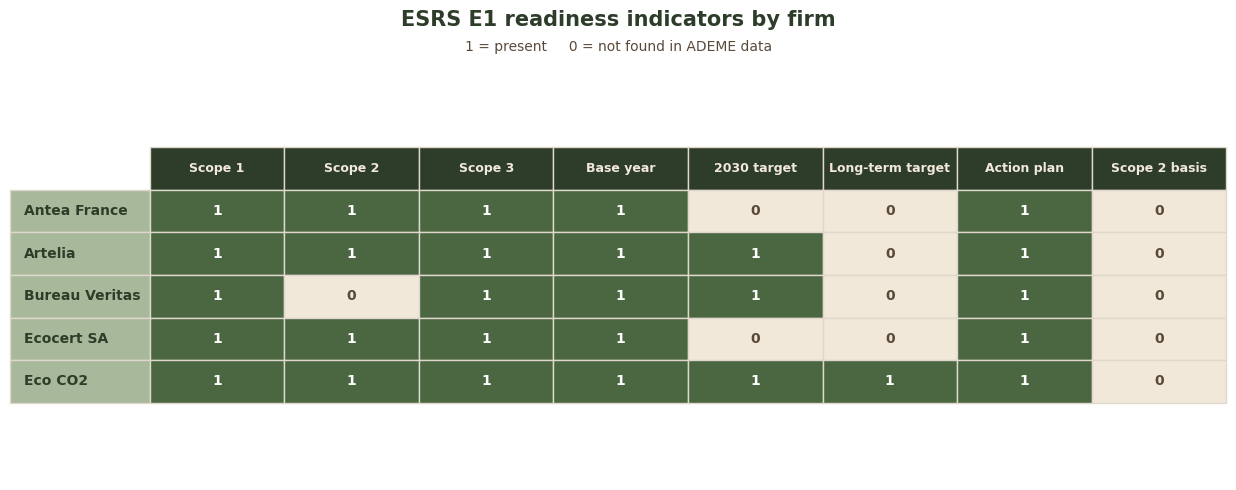

Saved.


In [8]:
plot_df = esrs_scores.drop("TOTAL").copy()

plot_df.columns = [
    "Scope 1",
    "Scope 2",
    "Scope 3",
    "Base year",
    "2030 target",
    "Long-term target",
    "Action plan",
    "Scope 2 basis",
]

colour_map = {0: "#f2e8d9", 1: "#4a6741"}
text_colour_map = {0: "#5a4a3a", 1: "white"}

fig, ax = plt.subplots(figsize=(13, 5))
ax.axis("off")

table = ax.table(
    cellText=plot_df.values,
    rowLabels=plot_df.index.tolist(),
    colLabels=plot_df.columns.tolist(),
    loc="center",
    cellLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 2.4)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#e0d8cc")
    if row == 0:
        cell.set_facecolor("#2d3d2a")
        cell.set_text_props(fontweight="bold", color="#f2e8d9", fontsize=9)
    elif col == -1:
        cell.set_facecolor("#a8b89a")
        cell.set_text_props(fontweight="bold", color="#2d3d2a", fontsize=10)
    else:
        val = plot_df.values[row - 1][col]
        cell.set_facecolor(colour_map[val])
        cell.set_text_props(color=text_colour_map[val], fontweight="bold")

fig.text(
    0.5, 0.97,
    "ESRS E1 readiness indicators by firm",
    ha="center", va="top",
    fontsize=15, fontweight="bold", color="#2d3d2a"
)
fig.text(
    0.5, 0.91,
    "1 = present     0 = not found in ADEME data",
    ha="center", va="top",
    fontsize=10, color="#5a4a3a"
)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig("../figures/esrs_checklist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [9]:
esrs_scores.to_csv("../data/processed/esrs_scores.csv")
print("Saved esrs_scores.csv")

import os
outputs = [
    "../figures/esrs_checklist.png",
    "../data/processed/esrs_scores.csv",
]
for path in outputs:
    exists = os.path.exists(path)
    size = os.path.getsize(path) if exists else 0
    print(f"{'OK' if exists else 'MISSING'}  {path}  ({size:,} bytes)")

Saved esrs_scores.csv
OK  ../figures/esrs_checklist.png  (51,790 bytes)
OK  ../data/processed/esrs_scores.csv  (321 bytes)


## Analytical findings

The ESRS E1 readiness check reveals a different pattern from the transparency 
scoring in NB03. Firms that scored well on methodology transparency do not 
necessarily show the strongest strategic climate disclosure in the ADEME fields.

All five firms disclose Scope 1 and Scope 3 emissions, establish a base year, 
and provide an action plan. Four of the five firms disclose Scope 2 emissions 
in the structured data. Bureau Veritas is the only firm in this sample without 
a positive Scope 2 value, which is notable because Scope 2 disclosure is a core 
ESRS E1 emissions datapoint and a basic expectation for organisations with offices, 
unless the emissions are reported elsewhere or omitted from the structured export.

Beyond this baseline, readiness becomes uneven. Three firms disclose a near-term 
2030 reduction target, while only Eco CO2 discloses a long-term climate target. 
No firm addresses the Scope 2 calculation basis in the ADEME data, meaning none 
distinguishes between location-based and market-based electricity emissions in the 
extracted fields. This is a significant gap because ESRS E1 expects Scope 2 
emissions to be reported using both location-based and market-based methods.

The most important systemic gaps are long-term target disclosure and Scope 2 
methodology. These are not minor details. They indicate whether a firm's carbon 
inventory is connected to a structured climate strategy rather than functioning 
only as a regulatory emissions declaration.

Eco CO2 scores highest with 7 out of 8 indicators present, mainly because it is 
the only firm with a long-term target in the extracted data. Artelia follows with 
6 out of 8. Antea France, Bureau Veritas, and Ecocert SA each score 5 out of 8. 
The gap between firms is narrower here than in NB02 or NB03, but the weaknesses 
are more consequential because they relate to strategic climate readiness rather 
than only reporting mechanics.